In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms


In [2]:
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,)),
                              ])

# Download and load the training data
trainset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.56MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.26MB/s]


Initial model with no softmax just ReLU, and Cross Entropy Loss

In [4]:
# Build a feed-forward network
model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

criterion = nn.CrossEntropyLoss()             # Define the loss (CrossEntropyLoss)
images, labels = next(iter(trainloader))      # Get data
images = images.view(images.shape[0], -1)     # Flatten
logits = model(images)                        # Forward pass, get our logits
loss = criterion(logits, labels)              # Calc the loss with the logits and the labels

print(loss)


tensor(2.3010, grad_fn=<NllLossBackward0>)


Second model with softmax and NLL Loss

In [5]:
# Build a feed-forward network
model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10),
    nn.LogSoftmax(dim=1)
)

criterion = nn.NLLLoss()             # Define the loss (CrossEntropyLoss)
images, labels = next(iter(trainloader))      # Get data
images = images.view(images.shape[0], -1)     # Flatten
logps = model(images)                        # Forward pass, get our log probabilities
loss = criterion(logps, labels)              # Calc the loss with the logits and the labels

print(loss)

tensor(2.3020, grad_fn=<NllLossBackward0>)


# Autograd

In [20]:
# Turning off gradients for a block of code
x = torch.zeros(1, requires_grad=True)
with torch.no_grad():
  y = x * 2
  print(y)
  print(y.requires_grad)

tensor([0.])
False


In [9]:
# Turn on or off gradients altogether with torch.set_grad_enabled(True|False)
x = torch.randn(2,2, requires_grad=True)
print(x)
y = x**2
print(y)

tensor([[ 0.5773,  0.2690],
        [-0.0104, -0.7059]], requires_grad=True)
tensor([[3.3329e-01, 7.2343e-02],
        [1.0774e-04, 4.9835e-01]], grad_fn=<PowBackward0>)


In [10]:
# grad_fn shows the function that generated this variable
print(y.grad_fn)

The autgrad module keeps track of these operations and knows how to calculate the gradient for each one. In this way, it's able to calculate the gradients for a chain of operations, with respect to any one tensor. Let's reduce the tensor `y` to a scalar value, the mean.

In [11]:
z = y.mean()
print(z)

tensor(0.2260, grad_fn=<MeanBackward0>)


In [12]:
# Gradients for x and y are empty
print(x.grad)

None


To calculate the gradients, you need to run the `.backward` method on a Variable, `z` for example. This will calculate the gradient for `z` with respect to `x`

$$
\frac{\partial z}{\partial x} = \frac{\partial}{\partial x}\left[\frac{1}{n}\sum_i^n x_i^2\right] = \frac{x}{2}
$$

In [13]:
z.backward()
print(x.grad)
print(x/2)

tensor([[ 0.2887,  0.1345],
        [-0.0052, -0.3530]])
tensor([[ 0.2887,  0.1345],
        [-0.0052, -0.3530]], grad_fn=<DivBackward0>)


# Loss and Autograd together

In [14]:
# Build a feed-forward network
model = nn.Sequential(nn.Linear(784, 128),
                      nn.ReLU(),
                      nn.Linear(128, 64),
                      nn.ReLU(),
                      nn.Linear(64, 10),
                      nn.LogSoftmax(dim=1))

criterion = nn.NLLLoss()
images, labels = next(iter(trainloader))
images = images.view(images.shape[0], -1)

logps = model(images)
loss = criterion(logps, labels)

In [15]:
print('Before backward pass: \n', model[0].weight.grad)
loss.backward()
print('After backward pass: \n', model[0].weight.grad)

Before backward pass: 
 None
After backward pass: 
 tensor([[-7.4168e-04, -7.4168e-04, -7.4168e-04,  ..., -7.4168e-04,
         -7.4168e-04, -7.4168e-04],
        [-8.9662e-05, -8.9662e-05, -8.9662e-05,  ..., -8.9662e-05,
         -8.9662e-05, -8.9662e-05],
        [ 3.5658e-03,  3.5658e-03,  3.5658e-03,  ...,  3.5658e-03,
          3.5658e-03,  3.5658e-03],
        ...,
        [-1.6158e-03, -1.6158e-03, -1.6158e-03,  ..., -1.6158e-03,
         -1.6158e-03, -1.6158e-03],
        [ 2.1780e-04,  2.1780e-04,  2.1780e-04,  ...,  2.1780e-04,
          2.1780e-04,  2.1780e-04],
        [-4.1438e-04, -4.1438e-04, -4.1438e-04,  ..., -4.1438e-04,
         -4.1438e-04, -4.1438e-04]])


# Training the network

In [16]:
from torch import optim

# Optimizers require the parameters to optimize and a learning rate
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [17]:
print('Initial weights - ', model[0].weight)

images, labels = next(iter(trainloader))
images.resize_(64, 784)

# Clear the gradients, because gradients are accumulated
optimizer.zero_grad()

# Forward pass, then backward pass, then update weights
output = model.forward(images)
loss = criterion(output, labels)
loss.backward()
print('Gradient -', model[0].weight.grad)

Initial weights -  Parameter containing:
tensor([[-0.0302, -0.0198,  0.0021,  ..., -0.0044,  0.0196, -0.0195],
        [-0.0355,  0.0213,  0.0139,  ...,  0.0331,  0.0144, -0.0304],
        [ 0.0150, -0.0018,  0.0122,  ...,  0.0051, -0.0321, -0.0127],
        ...,
        [-0.0280,  0.0136, -0.0160,  ...,  0.0014, -0.0200, -0.0269],
        [ 0.0031, -0.0136, -0.0135,  ...,  0.0050, -0.0334,  0.0140],
        [-0.0188, -0.0093, -0.0202,  ...,  0.0264, -0.0209,  0.0009]],
       requires_grad=True)
Gradient - tensor([[-1.3701e-03, -1.3701e-03, -1.3701e-03,  ..., -1.3701e-03,
         -1.3701e-03, -1.3701e-03],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.7682e-03,  2.7682e-03,  2.7682e-03,  ...,  2.7682e-03,
          2.7682e-03,  2.7682e-03],
        ...,
        [-2.8793e-03, -2.8793e-03, -2.8793e-03,  ..., -2.8793e-03,
         -2.8793e-03, -2.8793e-03],
        [ 3.2306e-03,  3.2306e-03,  3.2306e-03,  ...,  3.2306e

In [18]:
# Take an update step and new weights
optimizer.step()
print('Updated weights - ', model[0].weight)

Updated weights -  Parameter containing:
tensor([[-0.0302, -0.0198,  0.0021,  ..., -0.0043,  0.0197, -0.0195],
        [-0.0355,  0.0213,  0.0139,  ...,  0.0331,  0.0144, -0.0304],
        [ 0.0149, -0.0018,  0.0122,  ...,  0.0051, -0.0321, -0.0128],
        ...,
        [-0.0280,  0.0136, -0.0160,  ...,  0.0014, -0.0200, -0.0269],
        [ 0.0031, -0.0136, -0.0135,  ...,  0.0049, -0.0334,  0.0140],
        [-0.0188, -0.0093, -0.0202,  ...,  0.0264, -0.0209,  0.0009]],
       requires_grad=True)


# Training for real

In [19]:
model = nn.Sequential(nn.Linear(784, 128),
                      nn.ReLU(),
                      nn.Linear(128, 64),
                      nn.ReLU(),
                      nn.Linear(64, 10),
                      nn.LogSoftmax(dim=1))

criterion = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.003)

epochs = 5
for e in range(epochs):
    running_loss = 0
    for images, labels in trainloader:

        # Flatten MNIST images into a 784 long vector
        images = images.view(images.shape[0], -1)

        # Training pass
        optimizer.zero_grad()

        output = model.forward(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    else:
        print(f"Training loss: {running_loss/len(trainloader)}")

Training loss: 1.961726934416716
Training loss: 0.8697383183914461
Training loss: 0.5322510551478563
Training loss: 0.43569971287428444
Training loss: 0.39018809302910556


In [21]:
import numpy as np
import matplotlib.pyplot as plt

def view_classify(img, ps, version="MNIST"):
    ''' Function for viewing an image and it's predicted classes.
    '''
    ps = ps.data.numpy().squeeze()

    fig, (ax1, ax2) = plt.subplots(figsize=(6,9), ncols=2)
    ax1.imshow(img.resize_(1, 28, 28).numpy().squeeze())
    ax1.axis('off')
    ax2.barh(np.arange(10), ps)
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(10))
    if version == "MNIST":
        ax2.set_yticklabels(np.arange(10))
    elif version == "Fashion":
        ax2.set_yticklabels(['T-shirt/top',
                            'Trouser',
                            'Pullover',
                            'Dress',
                            'Coat',
                            'Sandal',
                            'Shirt',
                            'Sneaker',
                            'Bag',
                            'Ankle Boot'], size='small');
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)

    plt.tight_layout()

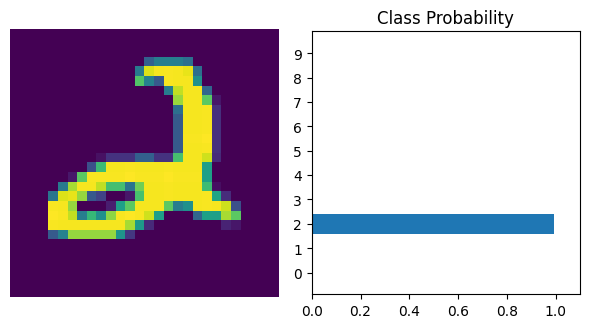

In [26]:
%matplotlib inline
import helper

images, labels = next(iter(trainloader))

img = images[0].view(1, 784)

# Turn off gradients to speed up this part
with torch.no_grad():
    logps = model.forward(img)

# Output of the network are logits, need to take softmax for probabilities
ps = torch.exp(logps)
view_classify(img.view(1, 28, 28), ps)